In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [2]:
df = pd.read_csv("validated_crop_data.csv")

df.head()

,Area,Item,Year,Crop_Yield,Rainfall,Pesticides,Temperature
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [3]:
print(df.shape)

(28242, 7)


In [4]:
df.isnull().sum()

Area           0
Item           0
Year           0
Crop_Yield     0
Rainfall       0
Pesticides     0
Temperature    0
dtype: int64

In [5]:
duplicates = df.duplicated().sum()

print("Duplicate Records :",duplicates)

Duplicate Records : 2310


In [6]:
df = df.drop_duplicates()

print("Shape After Removing Duplicates")

print(df.shape)

Shape After Removing Duplicates
(25932, 7)


In [7]:
numeric_columns = [

    "Crop_Yield",

    "Rainfall",

    "Pesticides",

    "Temperature"

]

numeric_columns

['Crop_Yield', 'Rainfall', 'Pesticides', 'Temperature']

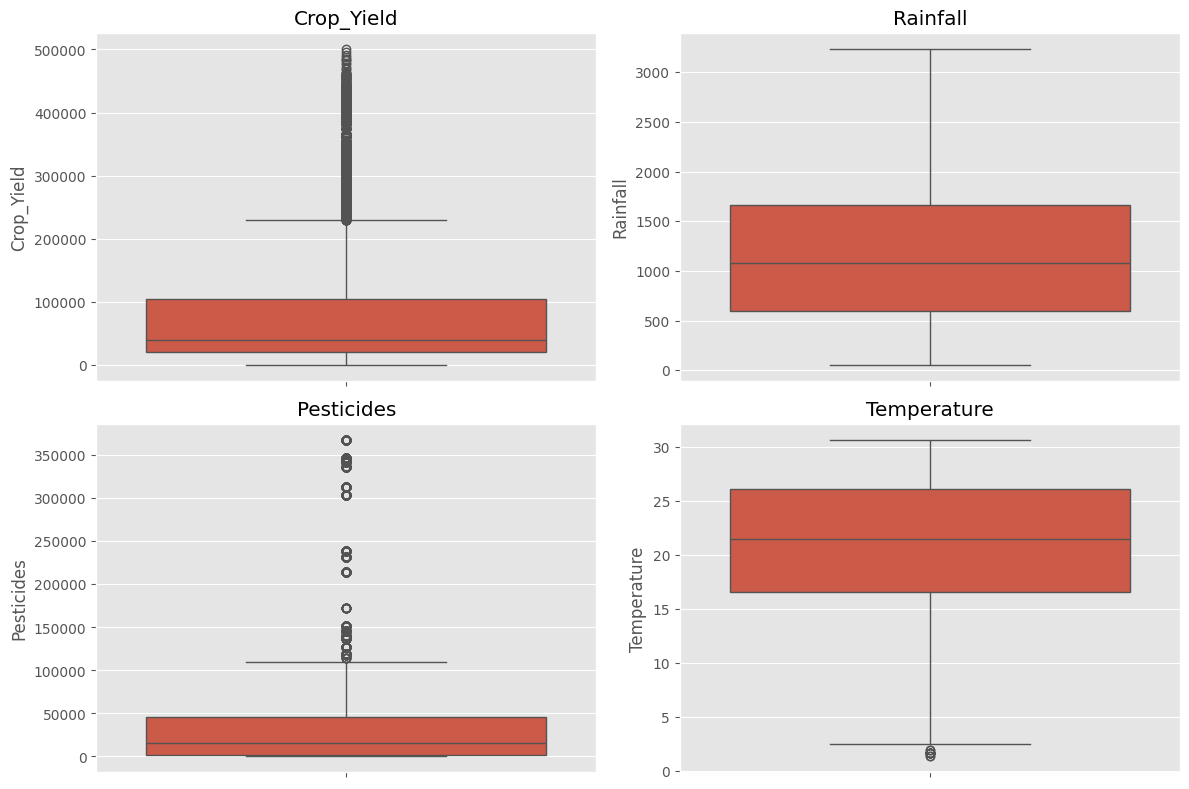

In [8]:
fig,ax = plt.subplots(

    2,

    2,

    figsize=(12,8)

)

for axis,column in zip(ax.flatten(),numeric_columns):

    sns.boxplot(

        y=df[column],

        ax=axis

    )

    axis.set_title(column)

plt.tight_layout()

plt.show()

In [9]:
def detect_outliers(data,column):

    Q1 = data[column].quantile(0.25)

    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR

    upper = Q3 + 1.5*IQR

    outliers = data[(data[column] < lower) |

                    (data[column] > upper)]

    return outliers

In [10]:
for column in numeric_columns:

    outliers = detect_outliers(df,column)

    print(column)

    print(len(outliers))

    print("-"*40)

Crop_Yield
1918
----------------------------------------
Rainfall
0
----------------------------------------
Pesticides
1262
----------------------------------------
Temperature
16
----------------------------------------


In [11]:
for column in numeric_columns:

    Q1 = df[column].quantile(.25)

    Q3 = df[column].quantile(.75)

    IQR = Q3-Q1

    lower = Q1 - 1.5*IQR

    upper = Q3 + 1.5*IQR

    df[column] = np.where(

        df[column] < lower,

        lower,

        np.where(

            df[column] > upper,

            upper,

            df[column]

        )

    )

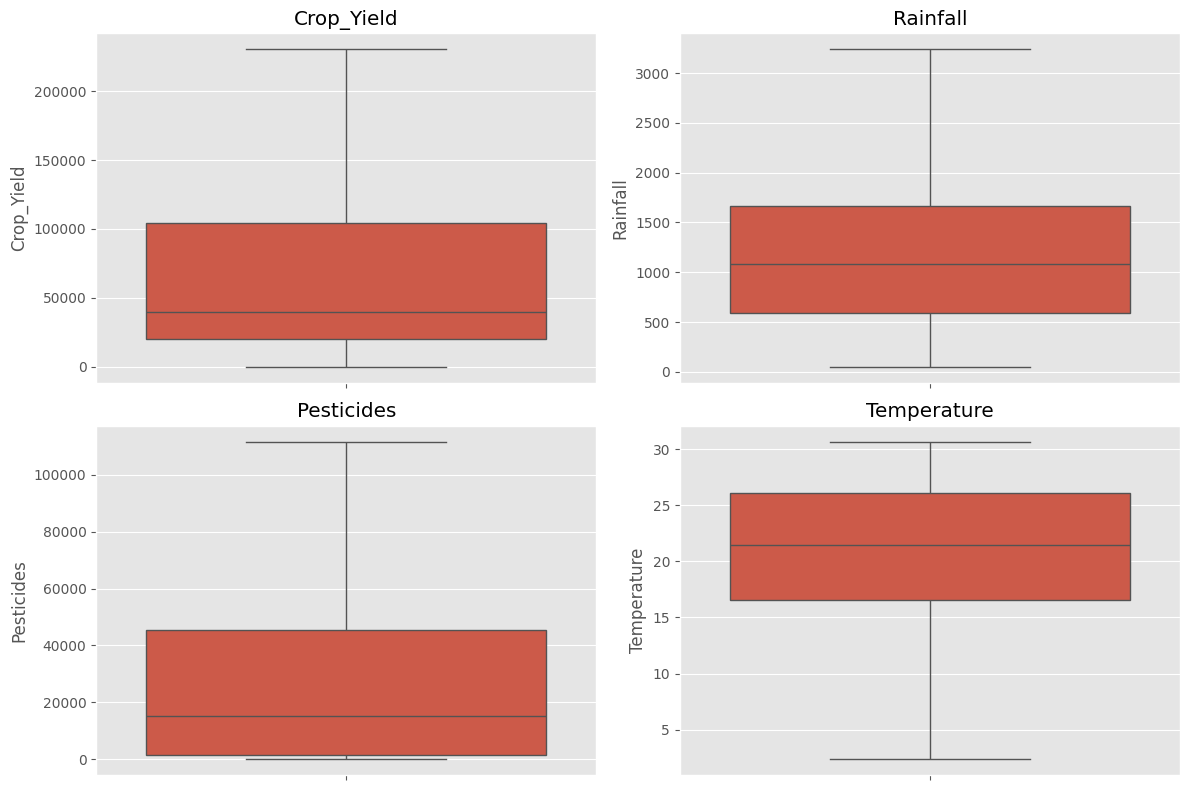

In [12]:
fig,ax = plt.subplots(

    2,

    2,

    figsize=(12,8)

)

for axis,column in zip(ax.flatten(),numeric_columns):

    sns.boxplot(

        y=df[column],

        ax=axis

    )

    axis.set_title(column)

plt.tight_layout()

plt.show()

In [13]:
df.dtypes

Area            object
Item            object
Year             int64
Crop_Yield     float64
Rainfall       float64
Pesticides     float64
Temperature    float64
dtype: object

In [14]:
df[numeric_columns].describe()

,Crop_Yield,Rainfall,Pesticides,Temperature
count,25932.000000,25932.000000,25932.000000,25932.000000
mean,71586.582639,1146.836688,28402.054292,20.422712
std,69413.690356,717.391098,31849.742375,6.438080
min,50.000000,51.000000,0.040000,2.360000
25%,19996.000000,593.000000,1597.000000,16.580000
50%,39530.000000,1083.000000,15373.000000,21.420000
75%,104168.000000,1668.000000,45620.000000,26.060000
max,230426.000000,3240.000000,111654.500000,30.650000


In [15]:
summary = pd.DataFrame({

    "Feature":numeric_columns,

    "Minimum":df[numeric_columns].min().values,

    "Maximum":df[numeric_columns].max().values,

    "Mean":df[numeric_columns].mean().values,

    "Median":df[numeric_columns].median().values

})

summary

,Feature,Minimum,Maximum,Mean,Median
0,Crop_Yield,50.00,230426.00,71586.582639,39530.00
1,Rainfall,51.00,3240.00,1146.836688,1083.00
2,Pesticides,0.04,111654.50,28402.054292,15373.00
3,Temperature,2.36,30.65,20.422712,21.42


In [16]:
summary.to_csv(

    "cleaning_summary.csv",

    index=False

)

In [17]:
df.to_csv(

    "cleaned_crop_data.csv",

    index=False

)

print("Clean Dataset Saved Successfully")

Clean Dataset Saved Successfully


In [18]:
print("="*60)

print("DATA CLEANING COMPLETED")

print("="*60)

print()

print("Rows :",len(df))

print("Columns :",len(df.columns))

print("Missing Values :",df.isnull().sum().sum())

print("Duplicates :",df.duplicated().sum())

print()

print("Dataset Ready For EDA")

DATA CLEANING COMPLETED

Rows : 25932
Columns : 7
Missing Values : 0
Duplicates : 0

Dataset Ready For EDA
